In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pathlib
import polars as pl

from pmw_analysis.constants import ArgSurfaceType
from pmw_analysis.constants import DIR_PMW_ANALYSIS, TC_COLUMNS, ArgTransform
from pmw_analysis.quantization.script import get_transformation_function

import datetime

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
# import ximage  # noqa

import gpm
from gpm.utils.geospatial import (
    get_circle_coordinates_around_point,
    get_country_extent,
    get_geographic_extent_around_point,
)

In [26]:
def get_pd_col(freq: int) -> str:
    return f"PD_{freq}"

def get_diff_col(tc_min: str, tc_sub: str) -> str:
    return f"{tc_min}_{tc_sub}"

def add_pd_var(ds, freq: int):
    v = f"Tc_{freq}V"
    h = f"Tc_{freq}H"
    return ds.assign({get_pd_col(freq): ds[v] - ds[h]})


def add_diff_var(ds, tc_min: str, tc_sub: str):
    return ds.assign({get_diff_col(tc_min, tc_sub): ds[tc_min] - ds[tc_sub]})

def transform_ds(ds, drop=False):
    initial_vars = ds.data_vars
    # PD variables
    ds = add_pd_var(ds, 19)
    ds = add_pd_var(ds, 37)

    # difference variables
    ds = add_diff_var(ds, "Tc_37V", "Tc_19V")
    ds = add_diff_var(ds, "Tc_89V", "Tc_37V")

    # dropping (same logic as your Polars code)
    if drop:
        keep = ["Tc_37V"]
        ds = ds.drop_vars([v for v in initial_vars if v not in keep])

    return ds

In [3]:
arg_transform = ArgTransform.V4
arg_surface_type = ArgSurfaceType.LAND
df_dir_path = pathlib.Path(DIR_PMW_ANALYSIS) / arg_transform.value / arg_surface_type.value

transform = get_transformation_function(arg_transform)
quant_columns = transform(TC_COLUMNS)

In [4]:
df_path = df_dir_path / "final_rarest_nbr_count_0_m_3_peaks_to_analyze.parquet"
df_peaks = pl.read_parquet(df_path)

In [50]:
df_peaks = df_peaks.sort("lon", descending=True)

In [81]:
peaks_indices = range(len(df_peaks))
df_peaks[peaks_indices]

time,lon,lat,Tc_37V,gpm_id,gpm_cross_track_id,temp2mIndex,distance,pd_19,pd_37,diff_37V_19V,diff_89V_37V,full_id
datetime[ns],f32,f32,f32,str,i64,f32,f64,f32,f32,f32,f32,str
2020-01-21 15:35:14,137.792419,-31.300032,283.450012,"""33508-2547""",90,301.0,7486.135804,56.679993,29.650009,17.860016,3.569977,"""33508-2547 90"""
2019-08-30 09:28:23,137.378922,-28.44838,257.630005,"""31264-2509""",136,288.0,9113.581082,72.12001,49.160004,18.470001,17.699982,"""31264-2509 136"""
2018-12-11 21:23:14,99.415771,-66.244804,207.419998,"""27197-23""",132,260.0,5442.527328,23.090012,19.099991,10.429993,-18.860001,"""27197-23 132"""
2020-02-02 19:21:31,96.501259,-65.508728,161.669998,"""33698-23""",118,268.0,1425.287186,27.479996,7.580002,-50.419998,39.669998,"""33698-23 118"""
2022-11-29 00:05:11,80.627792,35.470394,167.080002,"""49724-1863""",122,253.0,8861.617858,16.520004,10.220001,-36.0,-12.119995,"""49724-1863 122"""
…,…,…,…,…,…,…,…,…,…,…,…,…
2023-06-25 04:04:16,-61.429897,-66.438667,179.830002,"""52964-45""",136,250.0,8987.373421,22.230011,21.360001,19.979996,8.360001,"""52964-45 136"""
2021-10-13 16:17:19,-63.597034,-64.489403,250.229996,"""43324-2873""",108,273.0,2579.910168,44.889999,16.599991,14.209991,10.169998,"""43324-2873 108"""
2020-12-05 07:27:26,-67.565659,-20.289745,272.609985,"""38465-2365""",85,280.0,4177.184266,56.470001,39.809982,1.009979,-4.469971,"""38465-2365 85"""


In [84]:
# Specify the product and product type
product = "2A-DPR"  # 2A-PR
product_type = "RS"
storage = "GES_DISC"
# Specify the version
version = 7

ds_dpr_list = []
for i in peaks_indices:
    peak = df_peaks[i]

    # Specify the time period you are interested in
    timedelta = datetime.timedelta(minutes=1)
    start_time = peak["time"].item() - timedelta
    end_time = peak["time"].item() + timedelta

    # Download the data
    gpm.download(
        product=product,
        product_type=product_type,
        version=version,
        start_time=start_time,
        end_time=end_time,
        storage=storage,
        force_download=False,
        verbose=True,
        progress_bar=True,
        check_integrity=False,
    )

    # Load the 2A-DPR dataset
    ds = gpm.open_dataset(
        product=product,
        product_type=product_type,
        version=version,
        start_time=start_time,
        end_time=end_time,
        variables=[
            # "zFactorFinal",
            "zFactorMeasured",
            # 'flagSigmaZeroSaturation',
            # 'sigmaZeroCorrected',
            'sigmaZeroMeasured',
            # 'sigmaZeroNPCorrected',
            # 'sigmaZeroProfile',
            "precipRateNearSurface",
        ]
    )
    ds = ds.compute()
    ds_dpr_list.append(ds)

time,lon,lat,Tc_37V,gpm_id,gpm_cross_track_id,temp2mIndex,distance,pd_19,pd_37,diff_37V_19V,diff_89V_37V,full_id
datetime[ns],f32,f32,f32,str,i64,f32,f64,f32,f32,f32,f32,str
2018-12-11 21:23:14,99.415771,-66.244804,207.419998,"""27197-23""",132,260.0,5442.527328,23.090012,19.099991,10.429993,-18.860001,"""27197-23 132"""
2020-02-02 19:21:31,96.501259,-65.508728,161.669998,"""33698-23""",118,268.0,1425.287186,27.479996,7.580002,-50.419998,39.669998,"""33698-23 118"""


All the available GPM 2A-DPR product files are already on disk.
'scan_mode' has not been specified. Default to FS.


In [85]:
# Specify the product and product type
product = "1C-GMI-R"
product_type = "RS"
storage = "GES_DISC"
# Specify the version
version = 7

ds_pmw_list = []
for i in peaks_indices:
    peak = df_peaks[i]

    # Specify the time period you are interested in
    timedelta = datetime.timedelta(minutes=1)
    start_time = peak["time"].item() - timedelta
    end_time = peak["time"].item() + timedelta

    # Download the data
    gpm.download(
        product=product,
        product_type=product_type,
        version=version,
        start_time=start_time,
        end_time=end_time,
        storage=storage,
        force_download=False,
        verbose=True,
        progress_bar=True,
        check_integrity=False,
    )

    # Load the 1C-GMI-R dataset
    ds_pmw = gpm.open_dataset(
        product=product,
        product_type=product_type,
        version=version,
        start_time=start_time,
        end_time=end_time,
        variables=[
            "Tc",
        ]
    )
    ds_pmw = ds_pmw.compute()
    ds_pmw_list.append(ds_pmw)

All the available GPM 2A-DPR product files are already on disk.
'scan_mode' has not been specified. Default to FS.
All the available GPM 2A-DPR product files are already on disk.
'scan_mode' has not been specified. Default to FS.


In [86]:
from pmw_analysis.constants import DIR_IMAGES
from pmw_analysis.utils.io import combine_paths, file_to_dir

images_dir = combine_paths(path_base=pathlib.Path("..") / DIR_IMAGES, path_rel=file_to_dir(df_path), path_rel_base=DIR_PMW_ANALYSIS)
images_dir = images_dir / "peaks"
images_dir.mkdir(parents=True, exist_ok=True)

100%|██████████| 2/2 [00:02<00:00,  1.31s/it]


2 files has been download.
All the available GPM 1C-GMI-R product files are now on disk.
'scan_mode' has not been specified. Default to S1.


100%|██████████| 2/2 [00:04<00:00,  2.04s/it]


2 files has been download.
All the available GPM 1C-GMI-R product files are now on disk.
'scan_mode' has not been specified. Default to S1.


In [87]:
for idx, i in enumerate(peaks_indices):
    if idx == 0:
        continue
    peak = df_peaks[i]
    ds = ds_dpr_list[idx]

    variables_to_plot = ["sigmaZeroMeasured", "zFactorMeasured", "precipRateNearSurface"]

    fig, axes = plt.subplots(nrows=1, ncols=len(variables_to_plot), subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(12, 8))

    for ax, var in zip(axes, variables_to_plot):

        da = ds[var]
        if gpm.checks.has_vertical_dim(da):
            da = da.isel(range=0)
        if gpm.checks.has_frequency_dim(da):
            da = da.sel(radar_frequency="Ka")

        da.gpm.plot_map(ax=ax)
        ax.set_aspect("auto")

    plt.tight_layout()
    plt.savefig(images_dir / f"lon={peak['lon'].item():.2f}_lat={peak['lat'].item():.2f}_dpr.png")
    plt.show()


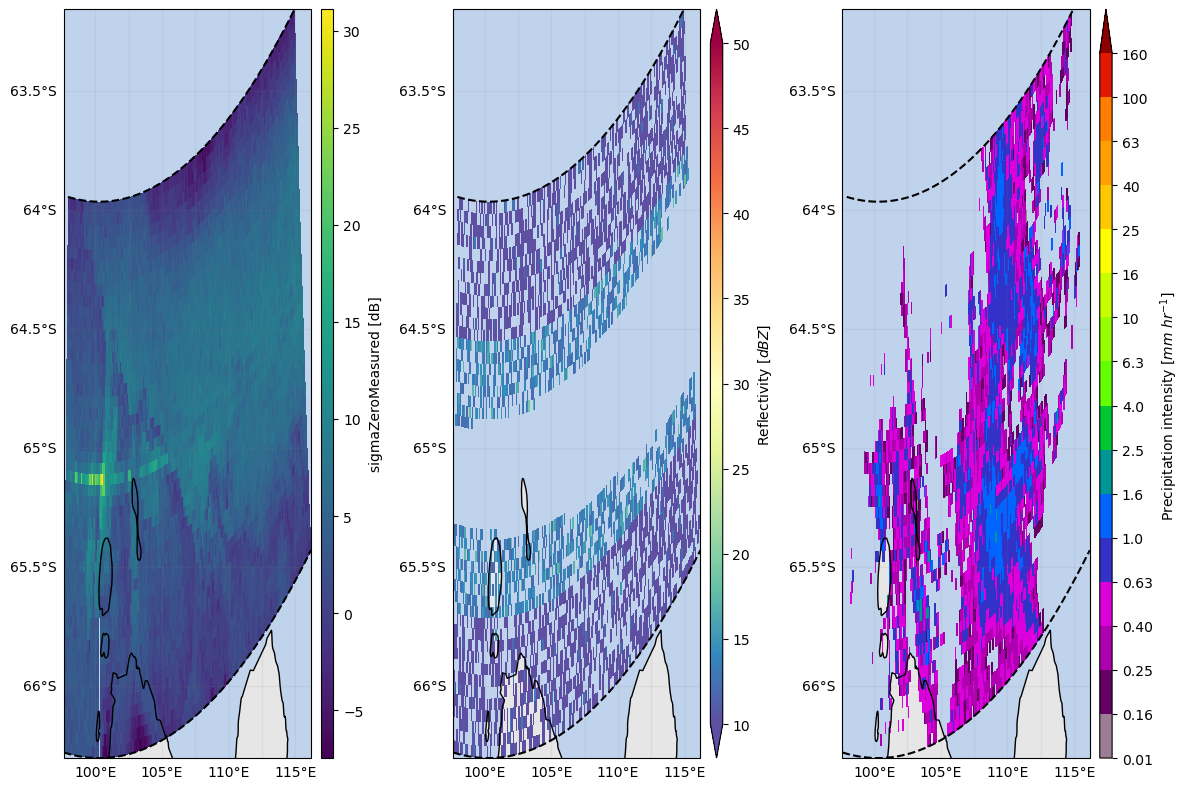

In [106]:
for idx, i in enumerate(peaks_indices):
    peak = df_peaks[i]
    ds_pmw = ds_pmw_list[idx]

    ds_tc = ds_pmw["Tc"].to_dataset(dim="pmw_frequency", promote_attrs=True)
    ds_tc = ds_tc.rename({var: "Tc_" + var for var in ds_tc.data_vars})
    ds_out = transform_ds(ds_tc, drop=True)

    da_pd = ds_out[["PD_19", "PD_37"]].to_array(dim="PD")
    da_diff = ds_out[["Tc_37V_Tc_19V", "Tc_89V_Tc_37V"]].to_array(dim="Diff")
    da_37 = ds_out["Tc_37V"]

    fc = da_pd.gpm.plot_map(col="PD", col_wrap=2, fig_kwargs=dict(figsize=(12, 6)))
    fc.remove_title_dimension_prefix()
    plt.savefig(images_dir / f"lon={peak['lon'].item():.2f}_lat={peak['lat'].item():.2f}_pd.png")

    fc = da_diff.gpm.plot_map(col="Diff", col_wrap=2, fig_kwargs=dict(figsize=(12, 6)))
    fc.remove_title_dimension_prefix()
    plt.savefig(images_dir / f"lon={peak['lon'].item():.2f}_lat={peak['lat'].item():.2f}_diff.png")

    fc = da_37.gpm.plot_map(fig_kwargs=dict(figsize=(6, 6)))
    plt.savefig(images_dir / f"lon={peak['lon'].item():.2f}_lat={peak['lat'].item():.2f}_37v.png")

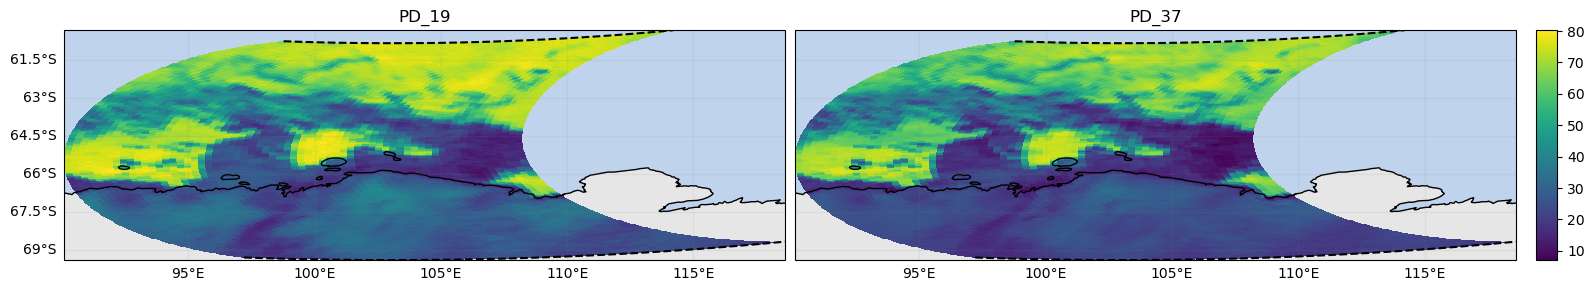

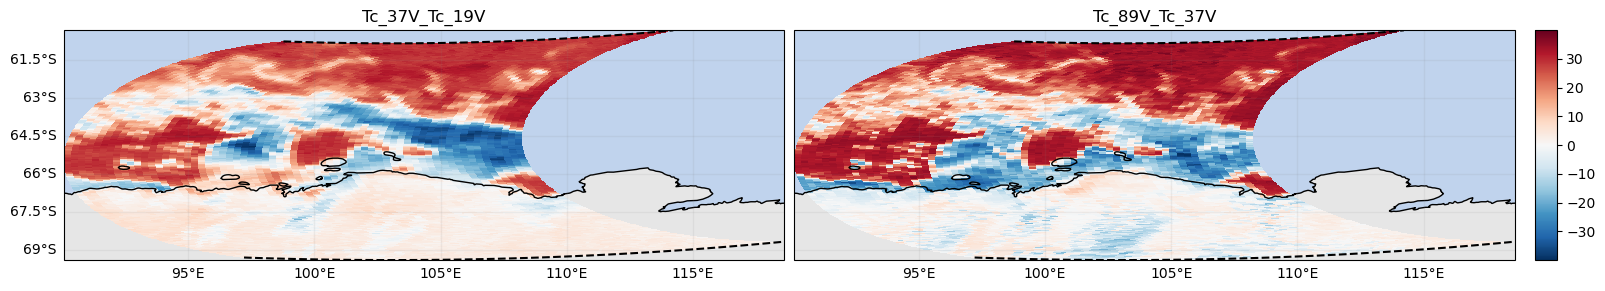

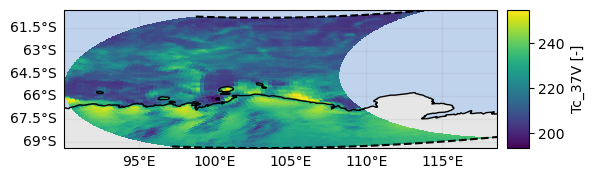

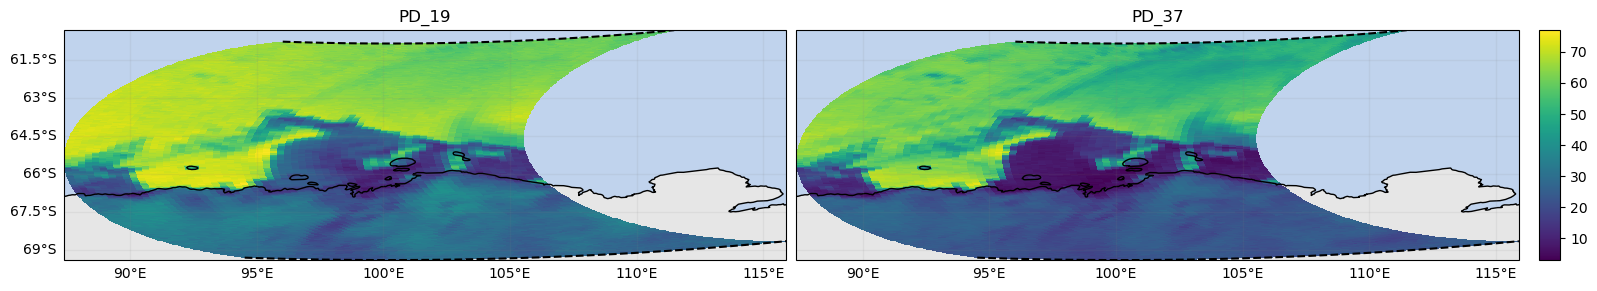

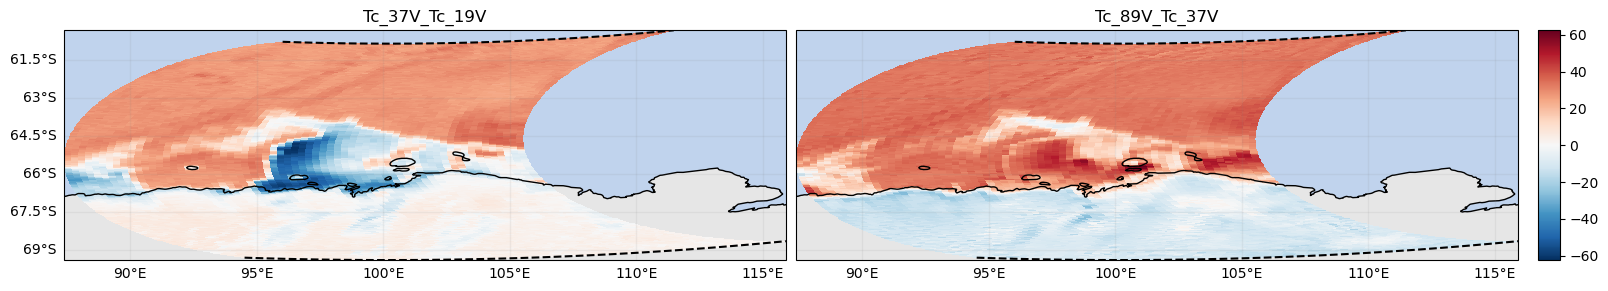

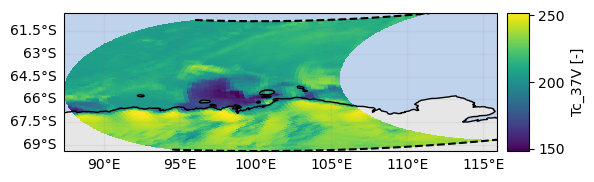